In [6]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index --Extension"


In [7]:

# Open and read the JSON file
with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [8]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
join_result_path = "../result/libspatialindex/HDD/4K/{name}/join/"

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_80000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}


data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'kdtree', 'kdtree_greedy', 'waffle', 'qdtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'qdtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'lisa', 'qdtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
# display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Waffle', 'Qd-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree', 'Kd-tree', 'GKd-tree', 'LISA', 'Qd-tree']

#### Join

../result/libspatialindex/HDD/4K/rtree/join/us_100000000_us_100000000_join_1000_2_uniform_1_0.001x0.001_quadratic.txt
../result/libspatialindex/HDD/4K/rtree/join/india_100000000_india_100000000_join_1000_2_uniform_1_0.001x0.001_quadratic.txt
../result/libspatialindex/HDD/4K/rtree/join/australia_100000000_australia_100000000_join_1000_2_uniform_1_0.001x0.001_quadratic.txt
../result/libspatialindex/HDD/4K/rtree/join/data_100000000_2_uniform_1_join_1000_2_uniform_1_0.001x0.001_quadratic.txt
../result/libspatialindex/HDD/4K/rtree/join/data_100000000_2_normal_1_join_1000_2_uniform_1_0.001x0.001_quadratic.txt
../result/libspatialindex/HDD/4K/rtree/join/data_100000000_2_skewed_4_join_1000_2_uniform_1_0.001x0.001_quadratic.txt
[370827.116304, 133564.837064, 1706733.95468, 4547.667422, 6651.35312, 5221.087954]
../result/libspatialindex/HDD/4K/r_star_tree/join/us_100000000_us_100000000_join_1000_2_uniform_1_0.001x0.001_rstar.txt
../result/libspatialindex/HDD/4K/r_star_tree/join/india_100000000_i

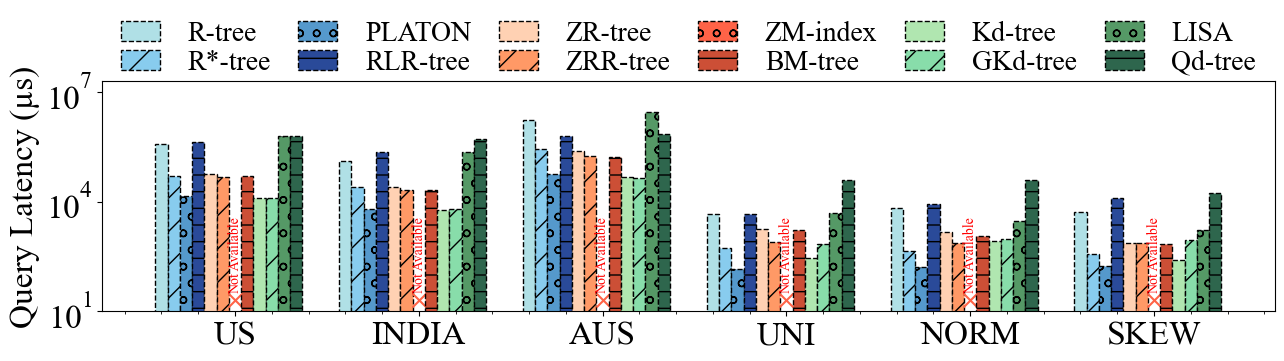

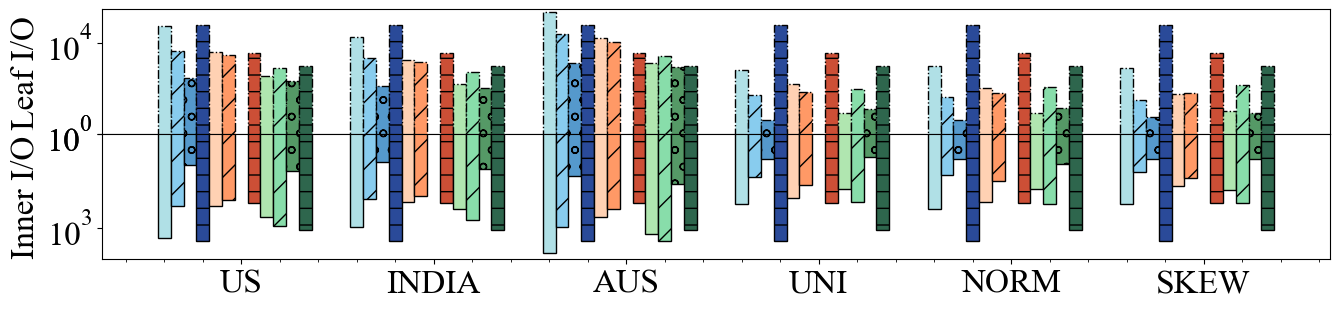

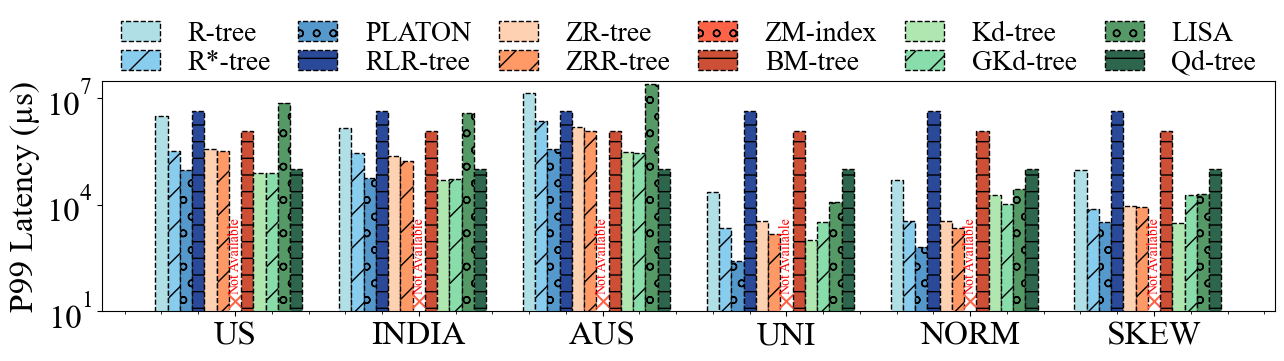

In [9]:

real_join_name_pattern = "{data_name}_join_1000_2_uniform_1_0.001x0.001"
synthetic_join_name_pattern = "join_1000_2_uniform_1_0.001x0.001"
join_result_name_pattern = "{data_name}{default_range_name}_{join_name}{suffix}.txt"

# real_point_name = "{data_name}_point_200000_2_uniform_1"
# synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
# point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"

result = []
IO = []

P99 = []
P50 = []

query_result_num = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            # print(suffix)
            
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            join_name = synthetic_join_name_pattern
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            join_name = real_join_name_pattern.format(data_name=data_name)
        
        join_result_name = join_result_name_pattern.format(
            data_name=data_name,
            join_name=join_name,
            default_range_name=default_range_name,
            suffix=suffix
        )

        
        res = os.path.join(join_result_path.format(name=baseline), join_result_name)
        # if baseline == 'rtree' and data_name == 'data_100000000_2_uniform_1':
        print(res)
        if baseline == 'rankspace_zorder':
            print(res)
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo)/1000)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
    if baseline == 'platon':
        print("platon", dataset_IO)
        print("platon", dataset_P99)
    if baseline == 'rankspace_zorder':
        print("rankspace_zorder", dataset_IO) 
    if baseline == 'bmtree':
        print('bmtree', dataset_results)
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num) 
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

    print(dataset_results)


plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/join_query_time.pdf", "../figs/exp_sigmod/join_query_time.png"], bottom=1e1, top=2*1e7, legend_location="top")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/join_query_IO.pdf", "../figs/exp_sigmod/join_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],
                bottom1=1, top1=300000, bottom2=1, top2=10000, legend_location="top")

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/join_query_P99.pdf", "../figs/exp_sigmod/join_query_P99.png"], bottom=1e1, top=3*1e7, legend_location="top")

# [[4155.363062, 4155.363352], [1948.486086, 1948.48696], [13671.837911, 13758.155001000001], [332.76193199999994, 249.264573], [263.433365, 186.893579], [159.371631, 143.44544699999997]]